# pmai-model-context

# Introduction
This notebook uses Hugging Face to train models for automatic image description (image captioning). With libraries such as Transformers, Datasets, and Accelerate

## **Estandar**

1. Codigo se desarrollara en ingles
2. Los prompts en español
3. Usar visualizadores

In [89]:
import importlib
import utils.cache as cache_utils
import utils.model as model_utils
import utils.context as context_utils
#___________________________________________________________________
from utils.decoder import base64_to_image
from utils.decoder import base64_to_image_resized
from utils.local_object import GlobalObjectForContext, context_info
from utils.local_object import GlobalObjectForContext

In [90]:
cache_utils = importlib.reload(cache_utils)
model_utils = importlib.reload(model_utils)
context_utils = importlib.reload(context_utils)
import_Blip_model = model_utils.import_Blip_model
get_quantized_blip_model = model_utils.get_quantized_blip_model
generate_context = context_utils.generate_context


In [80]:
import torch
import time
import os

torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except Exception:
    pass

#### 5 ) **Image Decoding**

In [81]:
with open("objetos/mycat.txt", "r", encoding="utf-8") as f:
    variablexenbase = f.read().strip()

In [69]:
pil_image = base64_to_image(variablexenbase)


In [70]:
pil_image = base64_to_image_resized(variablexenbase, size=(224, 224))

In [71]:
pil_image.show()


In [72]:
print(pil_image)

<PIL.Image.Image image mode=RGB size=224x224 at 0x16C5FD100>


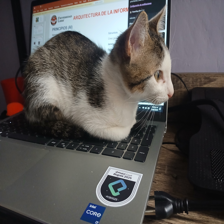

In [50]:
pil_image

In [95]:
processor, blip_model = import_Blip_model()

In [96]:
model_quantized = get_quantized_blip_model(
    blip_model,
    model_name=model_utils.MODEL_ID,
    engine="qnnpack",
    dtype=torch.qint8,
)

In [97]:
from pathlib import Path
import time

image_path = Path("objetos/yo.txt")
gen_kwargs = dict(
    max_length=50,
    min_length=15,
    num_beams=2,
    repetition_penalty=1.3,
    early_stopping=False,
    length_penalty=2.0,
    no_repeat_ngram_size=2,
    use_cache=True,
)

processor.image_processor.do_resize = True
processor.image_processor.do_center_crop = False
processor.image_processor.size = {"height": 128, "width": 128}

variablexenbase = image_path.read_text(encoding="utf-8").strip()

time_start = time.perf_counter()
pil_image = base64_to_image(variablexenbase)
inputs = processor(images=pil_image, return_tensors="pt").to("cpu")

with torch.inference_mode():
    output = model_quantized.generate(**inputs, **gen_kwargs)

contexto = processor.batch_decode(output, skip_special_tokens=True)[0]

elapsed = time.perf_counter() - time_start

print(f"contexto: {contexto}")
print(f"latency: {elapsed}s")

contexto: a group of people standing in front of a brick wall with their faces reflected in the glass
latency: 0.8550258750001376s


In [66]:

context = GlobalObjectForContext(
    id_global="",
    etiqueta="",
    confianza=0.0,
    contexto=None,
    sensores={},
    cameras_seen=[],
    camera_id=None,
    bbox=None,
    image_base64=None #aca se pone la imagen base 64
)


def guardar_contexto_en_txt(objeto, ruta="yo.txt"):
    with open(ruta, "w", encoding="utf-8") as f:
        f.write(objeto.contexto if objeto.contexto else ":()")

 